In [1]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
load_dotenv()

DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_PORT = os.getenv('DB_PORT')
DB_HOST = os.getenv('DB_HOST')

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [3]:
query = "SELECT * FROM texans_results;"
results_df = pd.read_sql(query, engine)

In [4]:
results_df.head()

,game_id,season,game_type,week,gameday,weekday,result,texans_score,opp_score,opponent,home_game,div_game,roof,surface,temp,wind
0,2002_01_DAL_HOU,2002,REG,1,2002-09-08,Sunday,win,19.0,10.0,DAL,1,0,closed,grass,NaN,NaN
1,2002_02_HOU_SD,2002,REG,2,2002-09-15,Sunday,loss,3.0,24.0,SD,0,0,outdoors,grass,74.0,8.0
2,2002_03_IND_HOU,2002,REG,3,2002-09-22,Sunday,loss,3.0,23.0,IND,1,1,open,grass,NaN,NaN
3,2002_04_HOU_PHI,2002,REG,4,2002-09-29,Sunday,loss,17.0,35.0,PHI,0,0,outdoors,fieldturf,64.0,10.0
4,2002_06_BUF_HOU,2002,REG,6,2002-10-13,Sunday,loss,24.0,31.0,BUF,1,0,closed,grass,NaN,NaN


In [5]:
# query Texans team data
query = "SELECT * FROM texans_team_stats;"
team_stats_df = pd.read_sql(query, engine)

In [6]:
team_stats_df.head()

,game_id,season_type,passing_epa,passing_cpoe,passing_tds,passing_interceptions,sacks_suffered,passing_yards,carries,rushing_yards,...,receiving_yards,def_sacks,def_interceptions,def_tackles_for_loss,def_qb_hits,def_pass_defended,fumbles_lost_total,penalties,penalty_yards,timeouts
0,2002_01_DAL_HOU,REG,-9.248628,NaN,2,1,6,145,35,87,...,145,3.0,1,4,3,12,0,11,80,3
1,2002_02_HOU_SD,REG,-28.893126,NaN,0,2,9,87,25,89,...,87,2.0,1,5,1,4,1,12,73,3
2,2002_03_IND_HOU,REG,-13.193301,NaN,0,1,4,99,30,126,...,99,3.0,0,7,3,3,1,9,67,4
3,2002_04_HOU_PHI,REG,-11.204414,NaN,2,2,7,188,24,91,...,188,3.0,1,3,3,11,1,11,83,3
4,2002_06_BUF_HOU,REG,0.364768,NaN,2,0,5,223,29,141,...,223,3.0,0,4,1,8,0,11,75,6


In [7]:
# query player stats
query = "SELECT * FROM texans_player_stats;"
player_stats_df = pd.read_sql(query, engine)

In [8]:
player_stats_df.head()

,player_id,player_name,position,game_id,completions,attempts,passing_epa,passing_cpoe,passing_yards,passing_tds,...,receiving_yards,receiving_epa,target_share,wopr,def_sacks,def_interceptions,def_tackles_for_loss,def_qb_hits,def_pass_defended,def_fumbles
0,00-0000210,James Allen,RB,2002_01_DAL_HOU,0,0,NaN,NaN,0,0,...,16,-6.060367,0.181818,0.972727,0.0,0,0,0,0,0
1,00-0001627,Corey Bradford,WR,2002_01_DAL_HOU,0,0,NaN,NaN,0,0,...,99,5.790326,0.272727,0.409091,0.0,0,0,0,0,0
2,00-0001931,Eric Brown,S,2002_01_DAL_HOU,0,0,NaN,NaN,0,0,...,0,NaN,0.000000,0.000000,0.0,0,0,0,0,0
3,00-0001980,Kris Brown,K,2002_01_DAL_HOU,0,0,NaN,NaN,0,0,...,0,NaN,0.000000,0.000000,0.0,0,0,0,0,0
4,00-0002720,Chris Carter,DB,2002_01_DAL_HOU,0,0,NaN,NaN,0,0,...,0,NaN,0.000000,0.000000,0.0,0,0,0,0,0


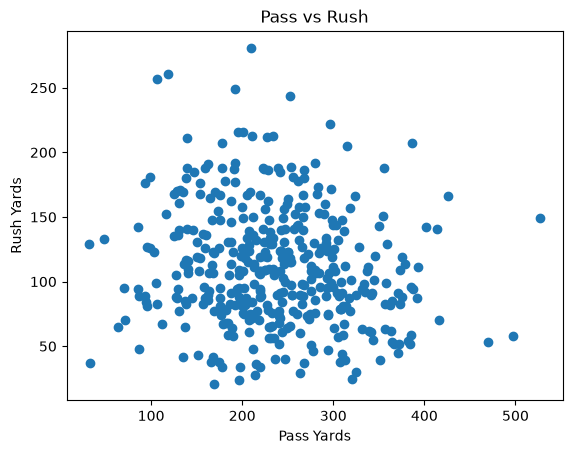

In [9]:
plt.scatter(team_stats_df["passing_yards"], team_stats_df["rushing_yards"])

plt.title("Pass vs Rush")
plt.xlabel("Pass Yards")
plt.ylabel("Rush Yards")

plt.show()

In [10]:
team_stats_df.columns.tolist()

['game_id',
 'season_type',
 'passing_epa',
 'passing_cpoe',
 'passing_tds',
 'passing_interceptions',
 'sacks_suffered',
 'passing_yards',
 'carries',
 'rushing_yards',
 'rushing_tds',
 'rushing_epa',
 'receiving_epa',
 'receiving_yards',
 'def_sacks',
 'def_interceptions',
 'def_tackles_for_loss',
 'def_qb_hits',
 'def_pass_defended',
 'fumbles_lost_total',
 'penalties',
 'penalty_yards',
 'timeouts']

In [11]:
results_df.columns.tolist()

['game_id',
 'season',
 'game_type',
 'week',
 'gameday',
 'weekday',
 'result',
 'texans_score',
 'opp_score',
 'opponent',
 'home_game',
 'div_game',
 'roof',
 'surface',
 'temp',
 'wind']

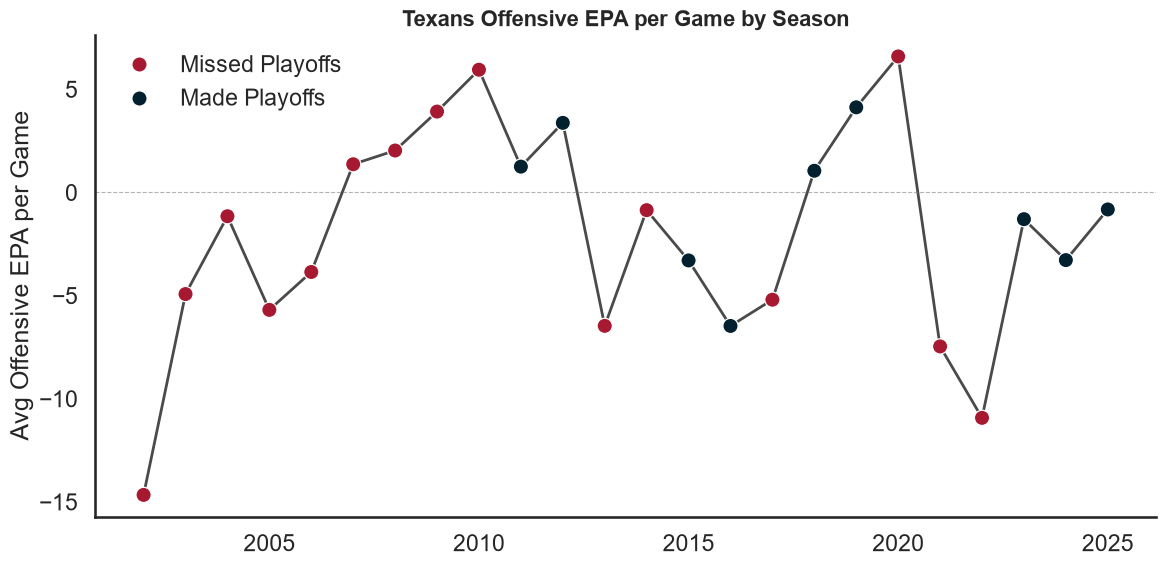

In [12]:
sns.set_theme(style="white", context="talk")

merged = team_stats_df.merge(
    results_df[['game_id', 'season', 'game_type', 'texans_score', 'opp_score']], on='game_id', how='left'
)

merged['offensive_epa'] = merged['passing_epa'] + merged['rushing_epa']
merged['win'] = merged['texans_score'] > merged['opp_score']

reg = merged[merged['game_type'] == 'REG']
season_stats = reg.groupby('season').agg(
    avg_offensive_epa=('offensive_epa', 'mean'),
    win_pct=('win', 'mean'),
    games=('game_id', 'count')
).reset_index()

playoff_seasons = merged.loc[merged['game_type'] != 'REG', 'season'].unique()
season_stats['made_playoffs'] = season_stats['season'].isin(playoff_seasons)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(season_stats['season'], season_stats['avg_offensive_epa'],
        color='#4A4A4A', linewidth=2, zorder=1)

sns.scatterplot(
    data=season_stats, x='season', y='avg_offensive_epa', hue='made_playoffs', palette={True: '#03202F', False: '#A71930'},
    s=120, ax=ax, zorder=2, legend=True
)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Texans Offensive EPA per Game by Season', fontsize=16, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('Avg Offensive EPA per Game')
sns.despine()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Missed Playoffs', 'Made Playoffs'], frameon=False, loc='upper left')

plt.tight_layout()
plt.show()